# Final Project
**Members:** Kris Nguyen, Anh Nguyen

# Thesis Statement:
Horror is the most economically efficient genre in Hollywood, consistently producing the highest Return on Investment (ROI) regardless of critical reception.

### 1. Data Collection and Preprocessing
The dataset used is an IMDb movies dataset containing financial data (budget and revenue) alongside genres and review scores. We benchmarked our analysis against the foundational film genres (Action, Comedy, Drama, Fantasy, Horror, Mystery, Romance, Thriller, Western) [1].

To ensure our analysis reflected the professional film industry rather than amateur projects or data-entry errors, we established a minimum production budget threshold of $$100,000. This eliminated placeholder "dummy data" (e.g., $1 budgets) that artificially skew math, restricting our scope to legitimately distributed feature films. 

We then calculated our primary metric: **Return on Investment (ROI)**, defined as `(Revenue - Budget) / Budget`.

Data set source: https://github.com/GettysburgDataScience/datasets/blob/main/movies/imdb_movies.csv

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset 
df = pd.read_csv('data/imdb_movies.csv')

# Remove missing values
df = df.dropna(subset=['budget_x', 'revenue', 'score', 'genre'])

# Filter out dummy data (budgets under $100,000)
df = df.query('budget_x >= 100000')

# Calculate ROI rate
df['ROI'] = (df['revenue'] - df['budget_x']) / df['budget_x']

# List of film genres
genres_to_compare = ['Action', 'Comedy', 'Drama', 'Fantasy', 'Horror', 'Mystery', 'Romance', 'Thriller', 'Western']

for g in genres_to_compare:
    df[g] = df['genre'].str.contains(g)

### 2. High-Level Metric: Average ROI by Genre
To motivate our thesis, we first compared the average Return on Investment across the nine basic Hollywood genres. 

This aggregate metric establishes the baseline for our argument: Horror significantly outperforms traditional blockbusters and prestige dramas in terms of percentage yield. By highlighting the horror genre, it becomes immediately apparent that it offers the highest financial reward relative to its cost.

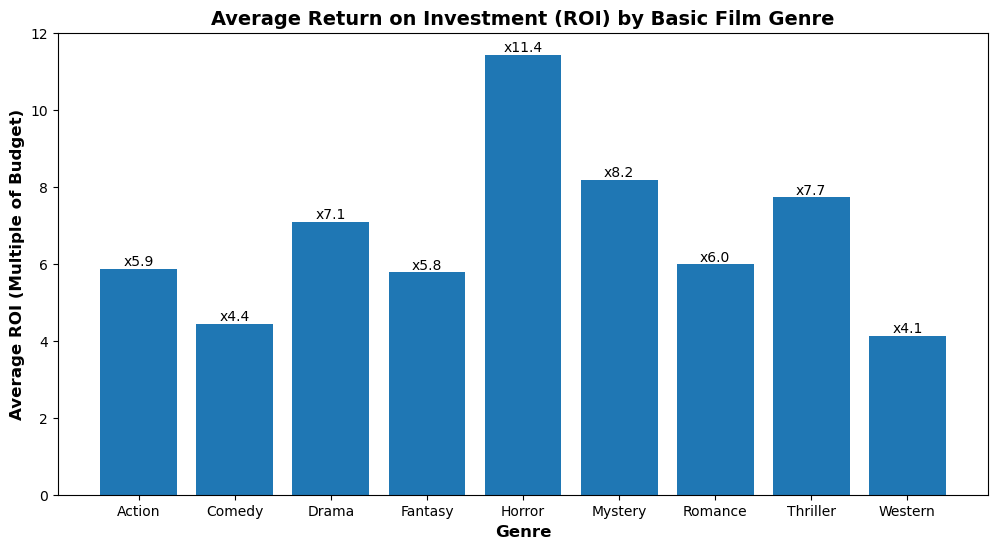

In [85]:
# Calculate the average ROI for each major genre
avg_rois = [df[df[g]]['ROI'].mean() for g in genres_to_compare]

# Create Bar Graph
plt.figure(figsize=(12, 6))
bars = plt.bar(genres_to_compare, avg_rois)

plt.title('Average Return on Investment (ROI) by Basic Film Genre', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12, fontweight='bold')
plt.ylabel('Average ROI (Multiple of Budget)', fontsize=12, fontweight='bold')

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'x{yval:.1f}', ha='center', va='bottom')

plt.show()

### 3. Finer Details: Reception Independence
A common assumption in the film industry is that a movie must be "good" (critically acclaimed) to make a profit. We isolated the Horror genre to test the direct correlation between critical review scores and financial success. 

The scatter plot below charts Review Scores against ROI, capped at a 10x return to focus on the main cluster of data. The line represents the "break-even" point (y = 0). As the flat trendline demonstrates, there is almost no correlation between a horror movie's critical score and its financial success. The vast majority of horror films sit comfortably above the break-even line, proving that the genre is largely "critic-proof."

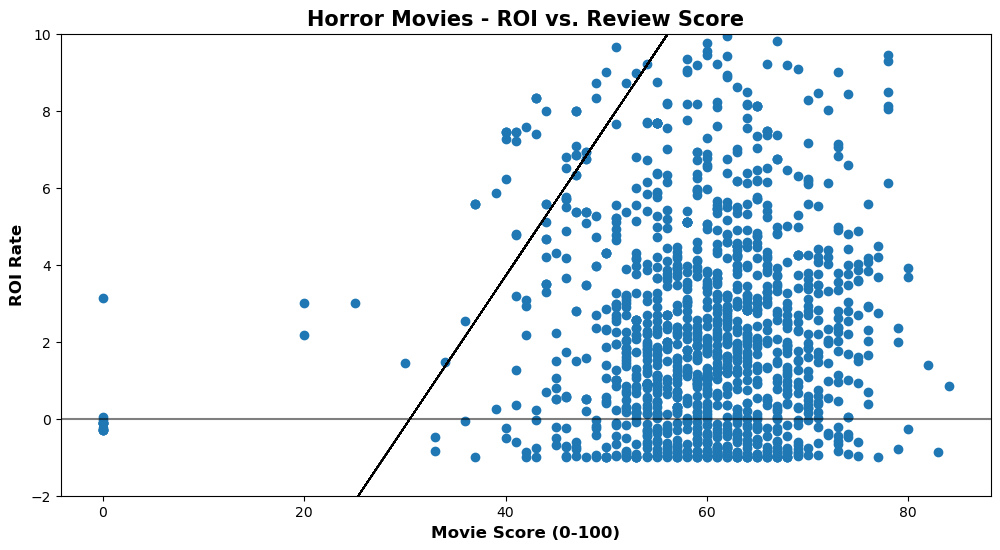

In [92]:
# Extract just the horror movies
horror_df = df[df['Horror']]

# Create Scatter Plot
plt.figure(figsize=(12, 6))
plt.scatter(horror_df['score'], horror_df['ROI'])

plt.title('Horror Movies - ROI vs. Review Score', fontsize=15, fontweight='bold')
plt.xlabel('Movie Score (0-100)', fontsize=12, fontweight='bold')
plt.ylabel('ROI Rate', fontsize=12, fontweight='bold')

# Add a trendline
z = np.polyfit(horror_df['score'], horror_df['ROI'], 1)
p = np.poly1d(z)
plt.plot(horror_df['score'], p(horror_df['score']), color='black', linewidth=1)

# Zoom in on the main cluster (-2 to 10x return) so the graph isn't broken by outliers
plt.ylim(-2, 10)

# Add a horizontal break-even line at y=0
plt.axhline(y=0, color='black', alpha=0.5)

#plt.legend()
plt.show()

### 4. Low-Risk Entry
If Horror yields the highest return, why doesn't it dominate the box office purely in total gross revenue? The core driver behind the horror genre's exceptional ROI is its remarkably low barrier to entry. 

By comparing the average production budgets across the basic film genres, we can visualize the second half of the efficiency equation: risk. Studios greenlight horror so frequently because the upfront financial risk is minimal. Compared to Action, Fantasy, or Sci-Fi blockbusters, Horror requires a fraction of the capital, making it the safest investment in the film industry.

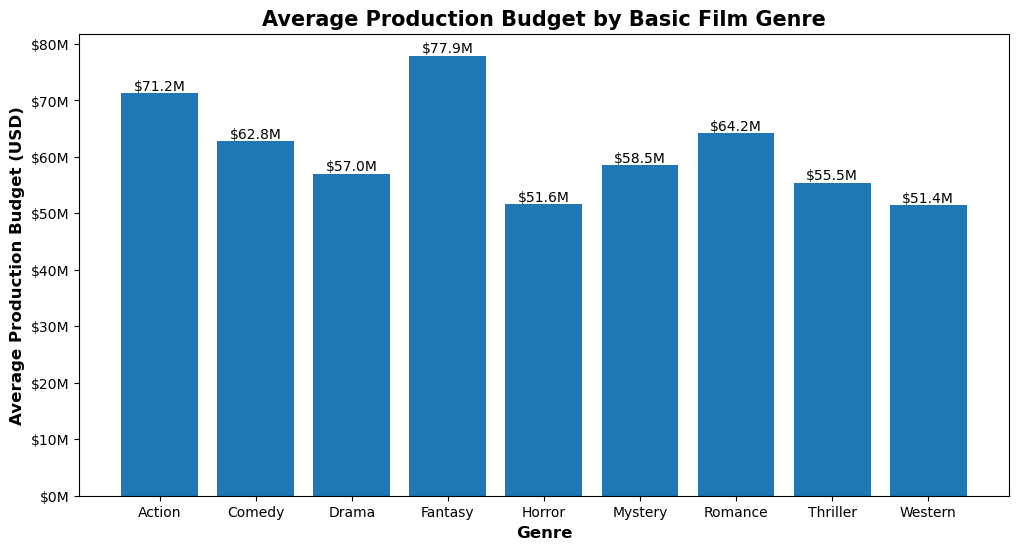

In [95]:
# Calculate the average production budget for each genre
avg_budgets = [df[df[g]]['budget_x'].mean() for g in genres_to_compare]

# Create Bar Graph
plt.figure(figsize=(12, 6))
bars = plt.bar(genres_to_compare, avg_budgets)

plt.title('Average Production Budget by Basic Film Genre', fontsize=15, fontweight='bold')
plt.xlabel('Genre', fontsize=12, fontweight='bold')
plt.ylabel('Average Production Budget (USD)', fontsize=12, fontweight='bold')

# Format the y-axis to show "Millions"
from matplotlib.ticker import FuncFormatter
def millions(x, pos):
    return f'${x*1e-6:.0f}M'
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    # Format the text to show "$XX.XM"
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'${yval*1e-6:.1f}M', ha='center', va='bottom')

plt.show()

*Citations:*
[1] PremiumBeat. "A Guide to Basic Film Genres." https://www.premiumbeat.com/blog/guide-to-basic-film-genres/

### Report
https://docs.google.com/document/d/1V7lCs1aDrzi4T5EeWfNMdvVFovdqq3C1TbdWqv-OaCQ/edit?tab=t.0